# 1
### (a) Predictions and Squared Errors

#### Model 1: $w = 0.5, b = 1$

$$
\hat{y} = 0.5x + 1
$$

| x | y | $\hat{y}$ | $(y - \hat{y})^2$ |
|--:|--:|----------:|------------------:|
| 1 | 2 |       1.5 |              0.25 |
| 2 | 3 |       2.0 |              1.00 |
| 3 | 5 |       2.5 |              6.25 |
| 4 | 4 |       3.0 |              1.00 |
| 5 | 6 |       3.5 |              6.25 |

$$
\text{Total Squared Error} = 0.25 + 1.00 + 6.25 + 1.00 + 6.25 = 14.75
$$

#### Model 2: $w = 1, b = 1$

$$
\hat{y} = x + 1
$$

| x | y | $\hat{y}$ | $(y - \hat{y})^2$ |
|--:|--:|----------:|------------------:|
| 1 | 2 |         2 |                 0 |
| 2 | 3 |         3 |                 0 |
| 3 | 5 |         4 |                 1 |
| 4 | 4 |         5 |                 1 |
| 5 | 6 |         6 |                 0 |

$$
\text{Total Squared Error} = 0 + 0 + 1 + 1 + 0 = 2
$$

#### Model 3: $w = 1.2, b = 0.5$

$$
\hat{y} = 1.2x + 0.5
$$

| x | y | $\hat{y}$ | $(y - \hat{y})^2$ |
|--:|--:|----------:|------------------:|
| 1 | 2 |       1.7 |              0.09 |
| 2 | 3 |       2.9 |              0.01 |
| 3 | 5 |       4.1 |              0.81 |
| 4 | 4 |       5.3 |              1.69 |
| 5 | 6 |       6.5 |              0.25 |

$$
\text{Total Squared Error} = 0.09 + 0.01 + 0.81 + 1.69 + 0.25 = 2.85
$$

#### Summary of Total Squared Errors

| Model | Equation               | Total Squared Error |
|-------|------------------------|--------------------:|
| 1     | $\hat{y} = 0.5x + 1$   |               14.75 |
| 2     | $\hat{y} = x + 1$      |                2.00 |
| 3     | $\hat{y} = 1.2x + 0.5$ |                2.85 |

The smallest total squared error is produced by:

$$
\boxed{\hat{y} = x + 1}
$$

So the best of the three candidate lines is:

$$
\boxed{w = 1, b = 1}
$$

### (b) Simple Sketch of the Data Points


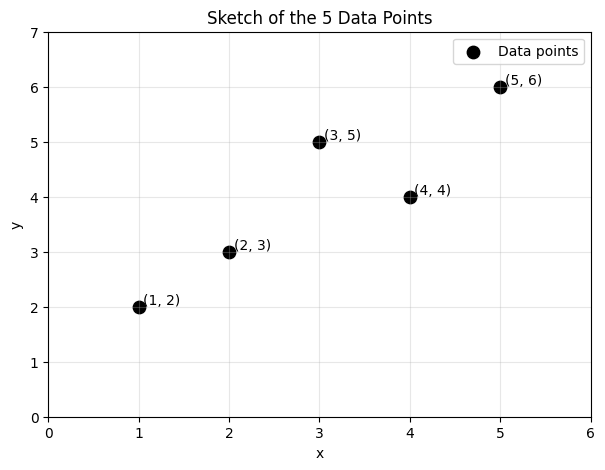

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])

plt.figure(figsize=(7, 5))

# Plot data points
plt.scatter(x, y, color="black", s=80, label="Data points")

# Label each point
for xi, yi in zip(x, y):
    plt.text(xi + 0.05, yi + 0.05, f"({xi}, {yi})", fontsize=10)

plt.title("Sketch of the 5 Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 7)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### (c) Sketch with the Three Candidate Lines

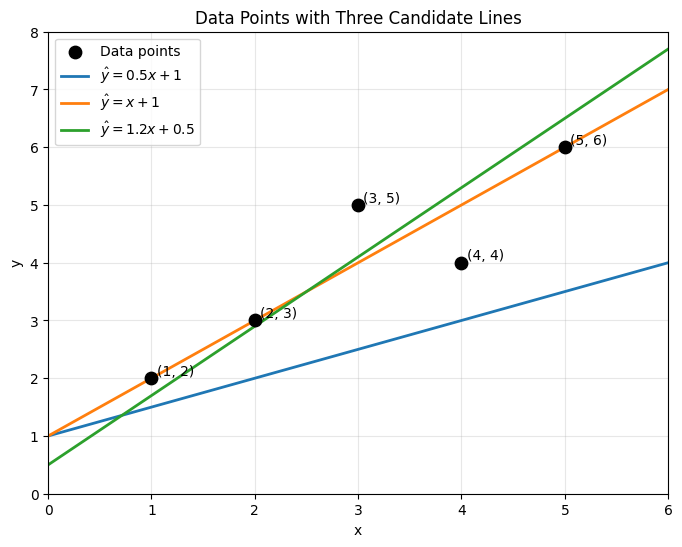

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])

# Candidate parameter choices
models = [
    {"w": 0.5, "b": 1.0, "label": r"$\hat{y} = 0.5x + 1$"},
    {"w": 1.0, "b": 1.0, "label": r"$\hat{y} = x + 1$"},
    {"w": 1.2, "b": 0.5, "label": r"$\hat{y} = 1.2x + 0.5$"},
]

# Smooth x-values for drawing lines
x_line = np.linspace(0, 6, 200)

plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(x, y, color="black", s=80, label="Data points", zorder=5)

# Label each point
for xi, yi in zip(x, y):
    plt.text(xi + 0.05, yi + 0.05, f"({xi}, {yi})", fontsize=10)

# Plot each candidate line
for model in models:
    w = model["w"]
    b = model["b"]
    y_line = w * x_line + b

    plt.plot(x_line, y_line, linewidth=2, label=model["label"])

plt.title("Data Points with Three Candidate Lines")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### (d) Interpretation
#### Best Line

The total squared errors for the three candidate lines are:

| Model | Equation               | Total Squared Error |
|-------|------------------------|--------------------:|
| 1     | $\hat{y} = 0.5x + 1$   |               14.75 |
| 2     | $\hat{y} = x + 1$      |                2.00 |
| 3     | $\hat{y} = 1.2x + 0.5$ |                2.85 |

The line with the smallest total squared error is:

$$
\hat{y} = x + 1
$$

So the best parameter choice is:

$$
w = 1, \quad b = 1
$$

This line gives the smallest total squared error of $2.00$.

#### Why Least Squares Is an Optimization Problem

Least squares can be viewed as an optimization problem because the goal is to find the parameter values that minimize prediction error. For the linear model:

$$
\hat{y} = wx + b
$$

Where the total squared error is:

$$
\text{Error}(w,b) = \sum_{i=1}^{n} \left(y_i - (wx_i + b)\right)^2
$$

Different choices of $w$ and $b$ produce different lines and therefore different total squared errors. Least squares searches for the values of $w$ and $b$ that make this error as small as possible.

#### Why Convexity Makes the Problem Easier

This problem is easier to reason about when the total squared error function is convex because a convex function has a bowl-shaped error surface with a clear minimum.

This means:

- There is one global minimum.
- Moving downhill on the error surface leads toward the best solution.
- Optimization methods such as gradient descent are more reliable.
- We do not have to worry about getting stuck in bad local minima.

For linear regression with squared error, the error function is convex in the parameters $w$ and $b$, which makes least squares easier to optimize and understand.

# 2
### (a) Basic Gradient Descent

Using learning rate $\alpha = 0.2$, the gradient descent update rule is:

$$w_{t+1} = w_t - \alpha f'(w_t)$$

#### Step 1

Current value:

$$w_0 = 0$$

Gradient:

$$f'(w_0) = 2(0 - 3) = -6$$

Update:

$$w_1 = 0 - 0.2(-6) = 1.2$$

#### Step 2

Current value:

$$w_1 = 1.2$$

Gradient:

$$f'(w_1) = 2(1.2 - 3) = -3.6$$

Update:

$$w_2 = 1.2 - 0.2(-3.6) = 1.92$$

#### Step 3

Current value:

$$w_2 = 1.92$$

Gradient:

$$f'(w_2) = 2(1.92 - 3) = -2.16$$

Update:

$$w_3 = 1.92 - 0.2(-2.16) = 2.352$$

#### Summary Table

| Step | Current $w_t$ | Gradient $f'(w_t)$ | Updated $w_{t+1}$ |
|------|--------------:|-------------------:|------------------:|
| 1    |             0 |                 -6 |               1.2 |
| 2    |           1.2 |               -3.6 |              1.92 |
| 3    |          1.92 |              -2.16 |             2.352 |

### (b) Adaptive-Style Update

The simplified adaptive update rule is:

$$w_{t+1} = w_t - \frac{\alpha g_t}{\sqrt{g_t^2} + \epsilon}$$

Where:

* $g_t = f'(w_t)$
* $\alpha = 0.2$
* $\epsilon = 10^{-8}$

Since $\sqrt{g_t^2} = |g_t|$, the update is approximately:

$$w_{t+1} = w_t - 0.2 \frac{g_t}{|g_t|}$$

Because the gradients are negative in these first steps, the update increases $w$ by approximately $0.2$ each time.

#### Step 1

Current value:

$$w_0 = 0$$

Gradient:

$$g_0 = f'(w_0) = 2(0 - 3) = -6$$

Update:

$$w_1 = 0 - \frac{0.2(-6)}{\sqrt{(-6)^2} + 10^{-8}}$$

$$w_1 = 0 - \frac{-1.2}{6 + 10^{-8}}$$

$$w_1 \approx 0.2$$

#### Step 2

Current value:

$$w_1 \approx 0.2$$

Gradient:

$$g_1 = f'(w_1) = 2(0.2 - 3) = -5.6$$

Update:

$$w_2 = 0.2 - \frac{0.2(-5.6)}{\sqrt{(-5.6)^2} + 10^{-8}}$$

$$w_2 = 0.2 - \frac{-1.12}{5.6 + 10^{-8}}$$

$$w_2 \approx 0.4$$

#### Step 3

Current value:

$$w_2 \approx 0.4$$

Gradient:

$$g_2 = f'(w_2) = 2(0.4 - 3) = -5.2$$

Update:

$$w_3 = 0.4 - \frac{0.2(-5.2)}{\sqrt{(-5.2)^2} + 10^{-8}}$$

$$w_3 = 0.4 - \frac{-1.04}{5.2 + 10^{-8}}$$

$$w_3 \approx 0.6$$

#### Summary Table

| Step | Current $w_t$ | Gradient $g_t=f'(w_t)$ | Updated $w_{t+1}$ |
|------|--------------:|-----------------------:|------------------:|
| 1    |             0 |                     -6 |     $\approx 0.2$ |
| 2    |           0.2 |                   -5.6 |     $\approx 0.4$ |
| 3    |           0.4 |                   -5.2 |     $\approx 0.6$ |

### (c) Compare the Behaviors

#### Which method changes $w$ by a larger amount?

Basic gradient descent changes $w$ by a larger amount in this example. Basic gradient descent updates:

$$0 \rightarrow 1.2 \rightarrow 1.92 \rightarrow 2.352$$

On the other hand, adaptive-style updates:

$$0 \rightarrow 0.2 \rightarrow 0.4 \rightarrow 0.6$$

So basic gradient descent moves much faster toward the minimum at $w = 3$.

#### Which method is less sensitive to gradient magnitude?

The adaptive-style update is less sensitive to gradient magnitude. This is because it divides by:

$$\sqrt{g_t^2} = |g_t|$$

So the magnitude of the update is approximately $\alpha = 0.2$ regardless of the size of the gradient, as long as the gradient is not close to zero.

#### What does this suggest about different optimizers?

Different optimizers may behave differently during training because they scale parameter updates differently. Basic gradient descent uses the raw gradient magnitude where:

- large gradients produce large updates
- small gradients produce small updates

On the other hand, adaptive-style methods normalize or rescale the gradient where:

- updating sizes can become less dependent on gradient magnitude
- training may be more stable when gradients vary greatly across parameters
- progress may be slower in simple cases like this example

This suggests that optimizer choice can strongly affect how quickly and stably model parameters are adjusted to reduce error.

# 3
### (a)

Model 1: Logistic Regression leads to a convex optimization problem when trained with binary cross-entropy loss, including optional $L_2$ regularization.

Model 2: A Small Neural Network leads to a non-convex optimization problem because it has multiple layers, nonlinear activations such as ReLU, and parameter interactions between layers.

### (b)

Optimization is generally easier for logistic regression because its loss surface is convex. This means there are no bad local minima: gradient descent is moving toward a global minimum, assuming appropriate conditions. In contrast, neural networks have non-convex loss surfaces with possible local minima, saddle points, flat regions, and many interacting parameters, making optimization more difficult.

### (c)

The neural network requires backpropagation because its output depends on parameters through multiple nested functions:

$$h = \text{ReLU}(W_1x + b_1)$$

$$\hat{y} = \sigma(W_2h + b_2)$$

To update parameters such as $W_1$, $b_1$, $W_2$, and $b_2$, we need to compute how the loss changes with respect to each parameter. Backpropagation efficiently applies the chain rule to compute these gradients layer by layer.

### (d)

Regularization helps control model complexity and reduce overfitting. For example, $L_2$ regularization adds a penalty term such as:

$$\lambda ||w||^2$$

This discourages very large weights and can lead to smoother, more generalizable models. In gradient-based learning, regularization changes the gradients so that the optimizer balances fitting the training data with keeping the parameters small.

### (e)

If the learning rate is too small, training will be very slow because each gradient descent step only makes a tiny update. The model may appear to make little progress and require many iterations to reach a good solution. If the learning rate is too large, training may become unstable. The loss can oscillate, fail to decrease, or even diverge because the optimizer overshoots good parameter values.

### (f)

Learning is an optimization process because training a model means adjusting its parameters to minimize a loss function. However, the difficulty of this optimization depends on the structure of the model. Logistic regression has a convex objective, so optimization is relatively straightforward. Neural networks have nonlinear layered structures, which create non-convex loss surfaces and make optimization more challenging.